In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split, learning_curve
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.isnull().sum())

#missing values in Age, Cabin, and Embarked

Train shape: (891, 12)
Test shape: (418, 11)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
#Data filling for missing values

def clean_data(df):
    # Age: fill with median grouped by Sex and Pclass
    df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )
    # Embarked: fill with mode
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    # Fare: fill with median
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    # Cabin: too many missing, just flag whether it exists
    df['HasCabin'] = df['Cabin'].notna().astype(int)
    return df

train = clean_data(train)
test  = clean_data(test)
print("Missing values after cleaning:")
print(train.isnull().sum())

Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
HasCabin         0
dtype: int64


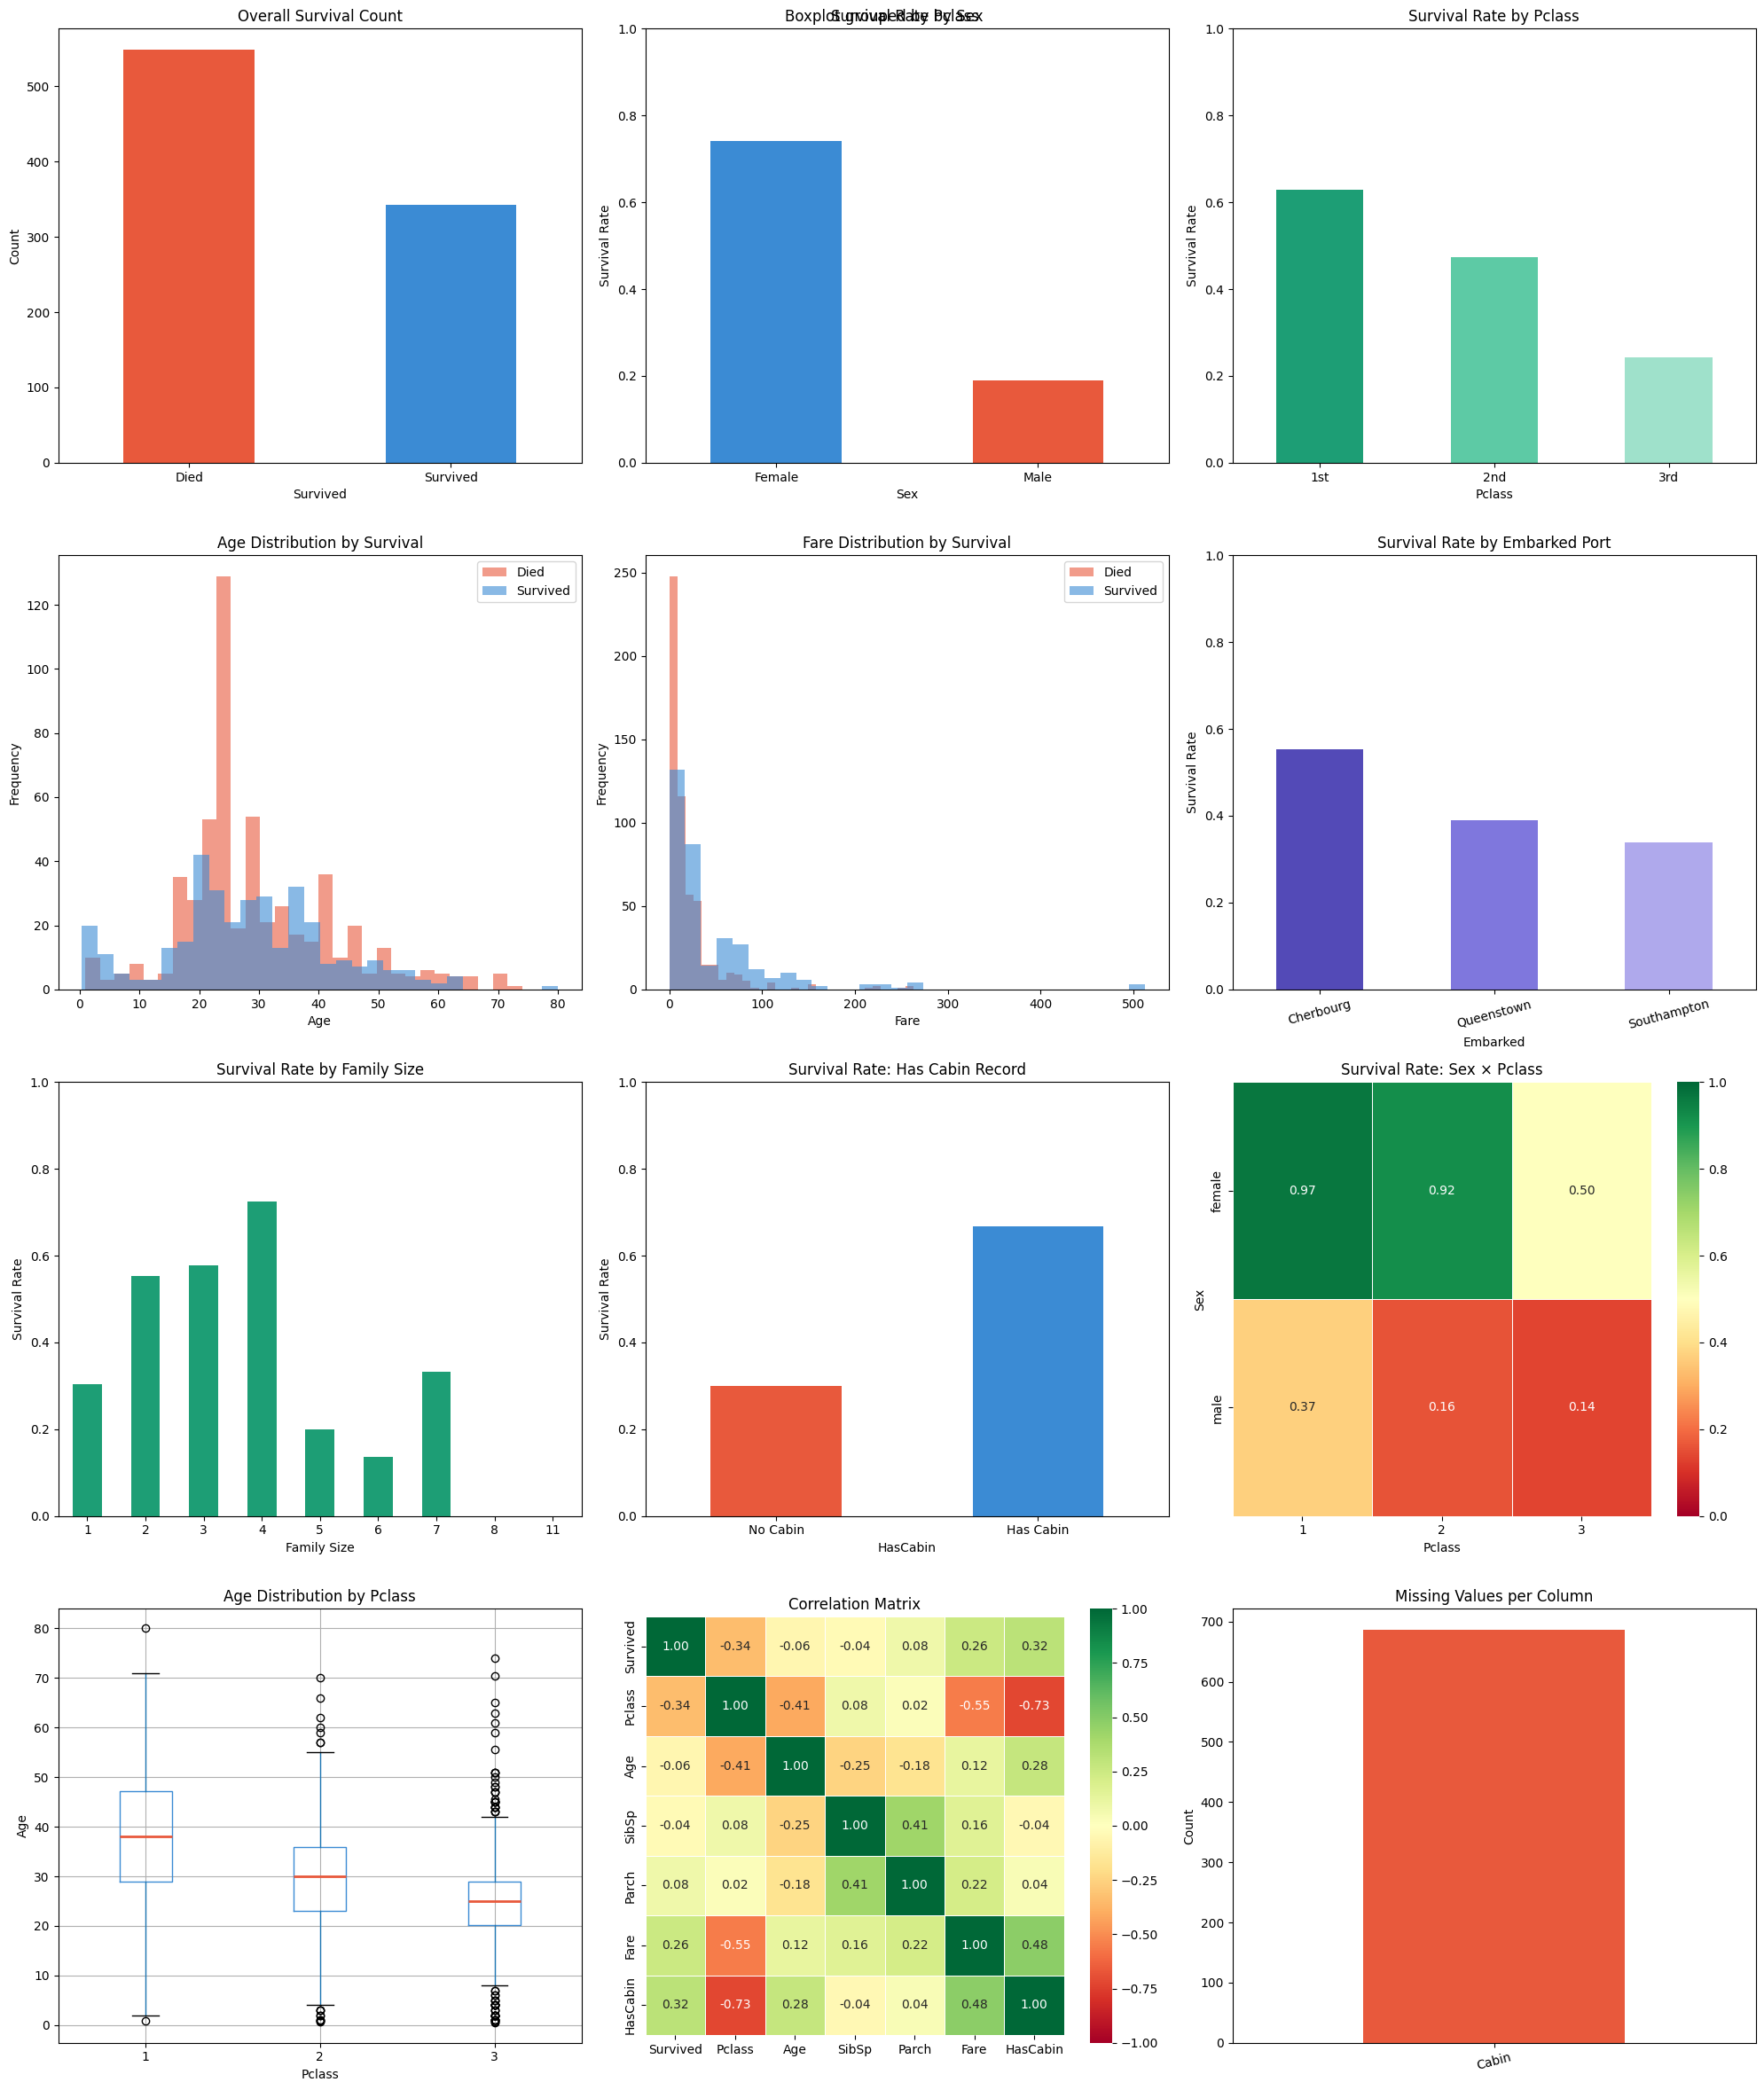

In [9]:
#Feature visualization

import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(20, 24))
fig.suptitle('Titanic EDA - Feature Overview', fontsize=16, y=1.01)

# 1. Survival rate overall
ax1 = fig.add_subplot(4, 3, 1)
train['Survived'].value_counts().plot(kind='bar', ax=ax1,
    color=['#E8593C','#3B8BD4'], edgecolor='none')
ax1.set_title('Overall Survival Count')
ax1.set_xticklabels(['Died', 'Survived'], rotation=0)
ax1.set_ylabel('Count')

# 2. Survival rate by Sex
ax2 = fig.add_subplot(4, 3, 2)
train.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=ax2,
    color=['#3B8BD4','#E8593C'], edgecolor='none')
ax2.set_title('Survival Rate by Sex')
ax2.set_ylabel('Survival Rate')
ax2.set_xticklabels(['Female', 'Male'], rotation=0)
ax2.set_ylim(0, 1)

# 3. Survival rate by Pclass
ax3 = fig.add_subplot(4, 3, 3)
train.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=ax3,
    color=['#1D9E75','#5DCAA5','#9FE1CB'], edgecolor='none')
ax3.set_title('Survival Rate by Pclass')
ax3.set_ylabel('Survival Rate')
ax3.set_xticklabels(['1st','2nd','3rd'], rotation=0)
ax3.set_ylim(0, 1)

# 4. Age distribution by survival
ax4 = fig.add_subplot(4, 3, 4)
train[train['Survived']==0]['Age'].dropna().plot(kind='hist', ax=ax4,
    bins=30, alpha=0.6, color='#E8593C', label='Died')
train[train['Survived']==1]['Age'].dropna().plot(kind='hist', ax=ax4,
    bins=30, alpha=0.6, color='#3B8BD4', label='Survived')
ax4.set_title('Age Distribution by Survival')
ax4.set_xlabel('Age')
ax4.legend()

# 5. Fare distribution by survival
ax5 = fig.add_subplot(4, 3, 5)
train[train['Survived']==0]['Fare'].plot(kind='hist', ax=ax5,
    bins=30, alpha=0.6, color='#E8593C', label='Died')
train[train['Survived']==1]['Fare'].plot(kind='hist', ax=ax5,
    bins=30, alpha=0.6, color='#3B8BD4', label='Survived')
ax5.set_title('Fare Distribution by Survival')
ax5.set_xlabel('Fare')
ax5.legend()

# 6. Survival rate by Embarked
ax6 = fig.add_subplot(4, 3, 6)
train.groupby('Embarked')['Survived'].mean().plot(kind='bar', ax=ax6,
    color=['#534AB7','#7F77DD','#AFA9EC'], edgecolor='none')
ax6.set_title('Survival Rate by Embarked Port')
ax6.set_ylabel('Survival Rate')
ax6.set_xticklabels(['Cherbourg','Queenstown','Southampton'], rotation=15)
ax6.set_ylim(0, 1)

# 7. Family size vs survival
ax7 = fig.add_subplot(4, 3, 7)
family_survival = train.copy()
family_survival['FamilySize'] = family_survival['SibSp'] + family_survival['Parch'] + 1
family_survival.groupby('FamilySize')['Survived'].mean().plot(kind='bar', ax=ax7,
    color='#1D9E75', edgecolor='none')
ax7.set_title('Survival Rate by Family Size')
ax7.set_xlabel('Family Size')
ax7.set_ylabel('Survival Rate')
ax7.set_xticklabels(ax7.get_xticklabels(), rotation=0)
ax7.set_ylim(0, 1)

# 8. HasCabin vs survival
ax8 = fig.add_subplot(4, 3, 8)
train.groupby('HasCabin')['Survived'].mean().plot(kind='bar', ax=ax8,
    color=['#E8593C','#3B8BD4'], edgecolor='none')
ax8.set_title('Survival Rate: Has Cabin Record')
ax8.set_xticklabels(['No Cabin', 'Has Cabin'], rotation=0)
ax8.set_ylabel('Survival Rate')
ax8.set_ylim(0, 1)

# 9. Pclass + Sex heatmap
ax9 = fig.add_subplot(4, 3, 9)
pivot = train.pivot_table('Survived', index='Sex', columns='Pclass', aggfunc='mean')
sns.heatmap(pivot, ax=ax9, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5)
ax9.set_title('Survival Rate: Sex × Pclass')

# 10. Age boxplot by Pclass
ax10 = fig.add_subplot(4, 3, 10)
train.boxplot(column='Age', by='Pclass', ax=ax10,
    boxprops=dict(color='#3B8BD4'),
    medianprops=dict(color='#E8593C', linewidth=2))
ax10.set_title('Age Distribution by Pclass')
ax10.set_xlabel('Pclass')
ax10.set_ylabel('Age')
plt.sca(ax10)
plt.title('Age Distribution by Pclass')

# 11. Correlation heatmap (numeric columns only)
ax11 = fig.add_subplot(4, 3, 11)
numeric_cols = ['Survived','Pclass','Age','SibSp','Parch','Fare','HasCabin']
corr = train[numeric_cols].corr()
sns.heatmap(corr, ax=ax11, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
ax11.set_title('Correlation Matrix')

# 12. Missing values bar chart
ax12 = fig.add_subplot(4, 3, 12)
missing = train.isnull().sum()
missing = missing[missing > 0]
missing.plot(kind='bar', ax=ax12, color='#E8593C', edgecolor='none')
ax12.set_title('Missing Values per Column')
ax12.set_ylabel('Count')
ax12.set_xticklabels(ax12.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

In [10]:
# Feature engineering

def engineer_features(df):
    # Extract title from name
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
    title_map = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
        'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
        'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
        'Capt': 'Rare', 'Sir': 'Rare'
    }
    df['Title'] = df['Title'].map(title_map).fillna('Rare')

    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

    # Age bands
    df['AgeBand'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                           labels=['Child','Teen','Adult','Middle','Senior'])

    # Fare bands
    df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=[0,1,2,3])

    # Sex to numeric
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    # Encode categoricals
    df = pd.get_dummies(df, columns=['Embarked', 'Title', 'AgeBand'])

    # Drop columns not useful for model
    drop_cols = ['Name', 'Ticket', 'Cabin', 'PassengerId']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df

test_ids = test['PassengerId']

train_fe = engineer_features(train.copy())
test_fe  = engineer_features(test.copy())

# Align columns (test may miss some dummies)
train_fe, test_fe = train_fe.align(test_fe, join='left', axis=1, fill_value=0)

feature_cols = [c for c in train_fe.columns if c != 'Survived']
X = train_fe[feature_cols]
y = train_fe['Survived']
X_test_final = test_fe[feature_cols]

print("Features:", feature_cols)
print("X shape:", X.shape)

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'FareBand', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBand_Child', 'AgeBand_Teen', 'AgeBand_Adult', 'AgeBand_Middle', 'AgeBand_Senior']
X shape: (891, 23)


In [11]:
# model training and cross validation

scaler = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=6,
                                                  min_samples_leaf=4, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                      max_depth=3, random_state=42),
    'SVM':                 SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
}

print("=" * 55)
print(f"{'Model':<25} {'CV Accuracy':>12} {'Std':>8}")
print("=" * 55)

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    results[name] = scores
    print(f"{name:<25} {scores.mean():>12.4f} {scores.std():>8.4f}")

print("=" * 55)
best_name = max(results, key=lambda k: results[k].mean())
print(f"\nBest model: {best_name} ({results[best_name].mean():.4f})")

Model                      CV Accuracy      Std
Logistic Regression             0.8249   0.0212
Random Forest                   0.8260   0.0172
Gradient Boosting               0.8271   0.0279
SVM                             0.8316   0.0250

Best model: SVM (0.8316)


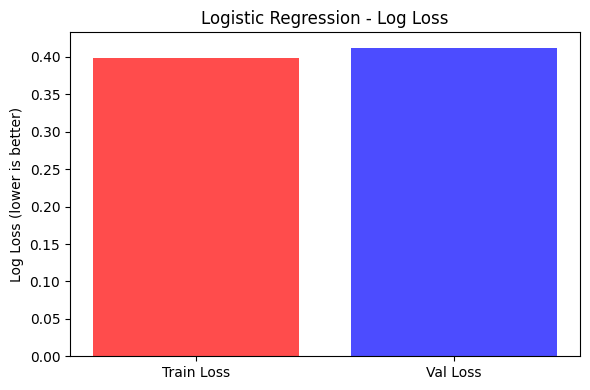

Logistic Regression       Train Loss: 0.3991  Val Loss: 0.4122


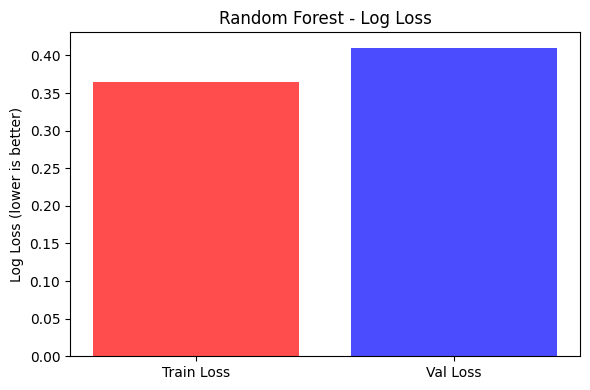

Random Forest             Train Loss: 0.3643  Val Loss: 0.4102


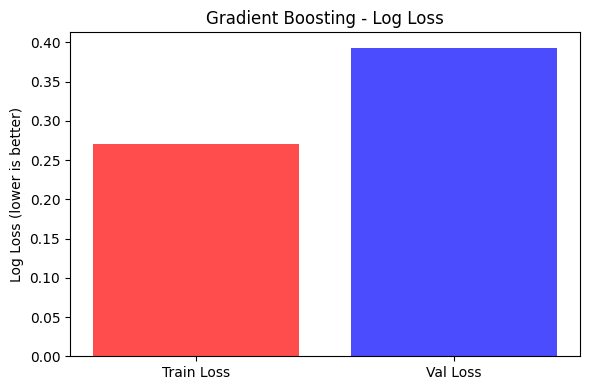

Gradient Boosting         Train Loss: 0.2706  Val Loss: 0.3932


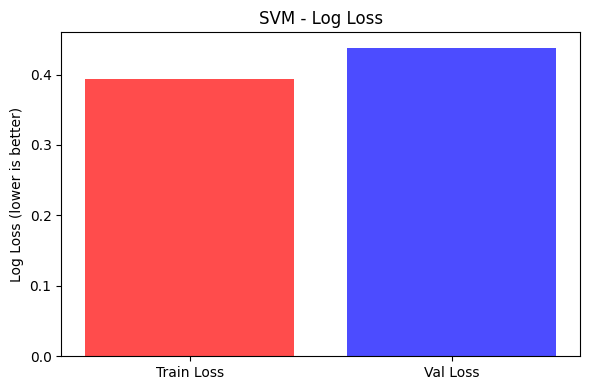

SVM                       Train Loss: 0.3943  Val Loss: 0.4380


In [12]:
#log loss evaluation and visualization

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import numpy as np

for name, model in models.items():
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_losses = []
    val_losses = []

    for train_idx, val_idx in kf.split(X_scaled, y):
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train, y_train)

        train_losses.append(log_loss(y_train, model.predict_proba(X_train)))
        val_losses.append(log_loss(y_val,   model.predict_proba(X_val)))

    plt.figure(figsize=(6, 4))
    plt.bar(['Train Loss', 'Val Loss'],
            [np.mean(train_losses), np.mean(val_losses)],
            color=['red', 'blue'], alpha=0.7)
    plt.title(f'{name} - Log Loss')
    plt.ylabel('Log Loss (lower is better)')
    plt.tight_layout()
    plt.savefig(f'loss_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()

    print(f"{name:<25} Train Loss: {np.mean(train_losses):.4f}  Val Loss: {np.mean(val_losses):.4f}")

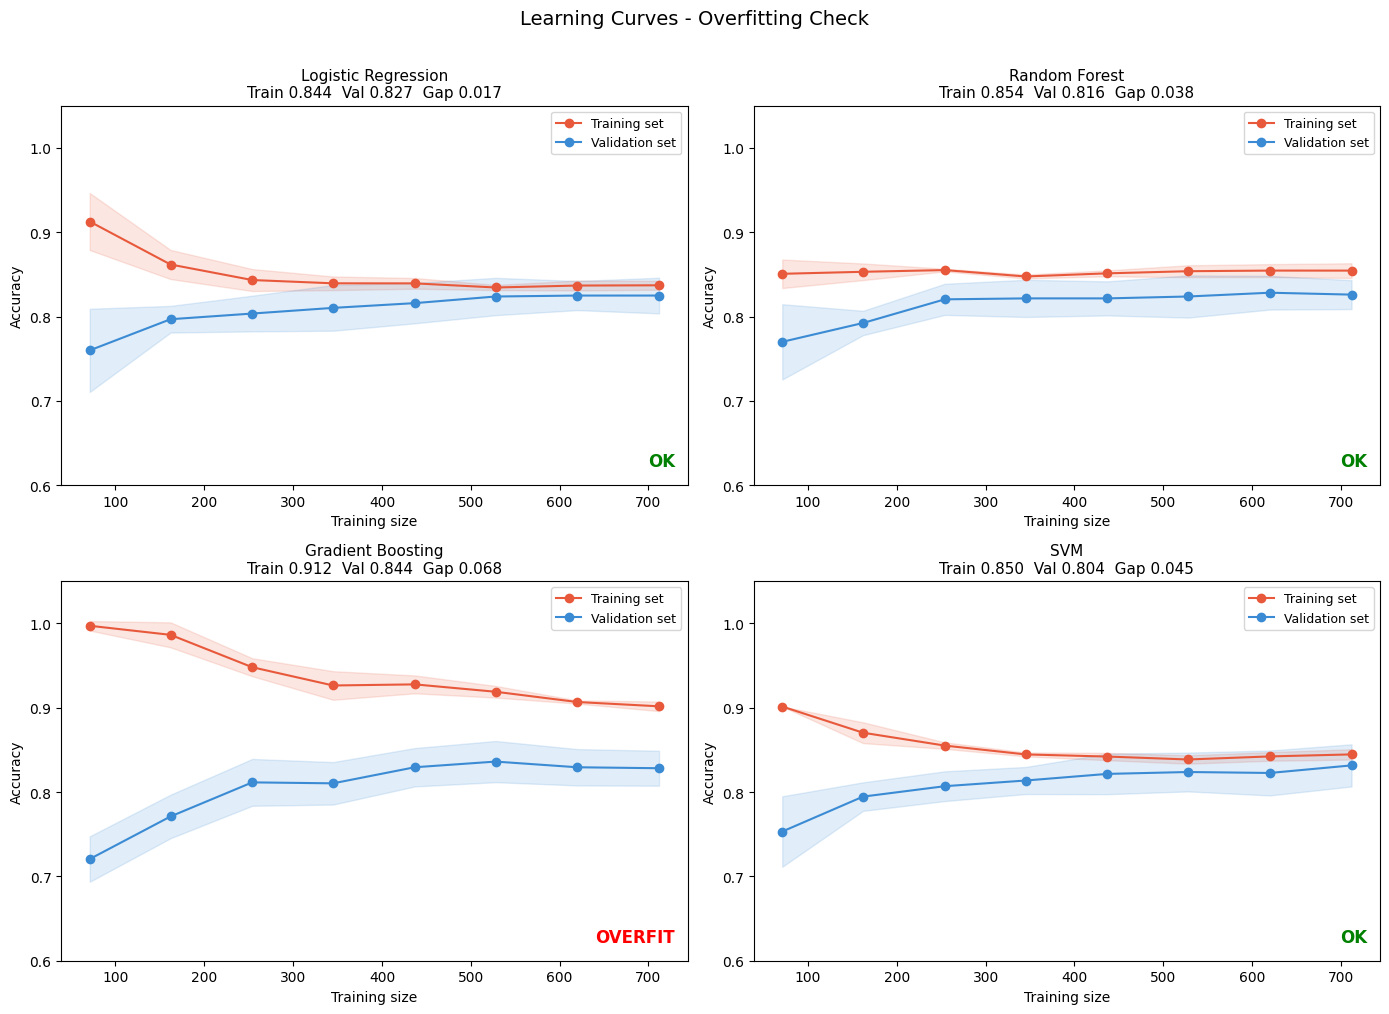


Classification report for best model (SVM):
              precision    recall  f1-score   support

        Died       0.81      0.87      0.84       105
    Survived       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    # Train/val split check
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    model.fit(X_tr, y_tr)
    train_acc = model.score(X_tr, y_tr)
    val_acc   = model.score(X_val, y_val)
    gap = train_acc - val_acc

    # Learning curve
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_scaled, y, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )

    ax = axes[idx]
    ax.plot(train_sizes, train_scores.mean(axis=1),
            'o-', color='#E8593C', label='Training set')
    ax.plot(train_sizes, val_scores.mean(axis=1),
            'o-', color='#3B8BD4', label='Validation set')
    ax.fill_between(train_sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.15, color='#E8593C')
    ax.fill_between(train_sizes,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.15, color='#3B8BD4')
    ax.set_title(f'{name}\nTrain {train_acc:.3f}  Val {val_acc:.3f}  Gap {gap:.3f}',
                 fontsize=11)
    ax.set_xlabel('Training size')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.set_ylim(0.6, 1.05)

    # Overfitting warning
    status = "OVERFIT" if gap > 0.05 else "OK"
    color  = 'red' if gap > 0.05 else 'green'
    ax.text(0.98, 0.05, status, transform=ax.transAxes,
            ha='right', color=color, fontweight='bold', fontsize=12)

plt.suptitle('Learning Curves - Overfitting Check', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Best model classification report
print(f"\nClassification report for best model ({best_name}):")
best_model = models[best_name]
best_model.fit(X_tr, y_tr)
print(classification_report(y_val, best_model.predict(X_val),
                            target_names=['Died', 'Survived']))

In [14]:
# Train best model on ALL training data
best_model = models[best_name]
best_model.fit(X_scaled, y)

predictions = best_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived':    predictions.astype(int)
})
submission.to_csv('submission.csv', index=False)
print("File saved!")
print(submission.head(10))
print(f"\nSurvived rate: {predictions.mean():.2%}")

File saved!
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Survived rate: 39.00%
